# INFO Tracking 2 magnets

This example simulates two static magnets separated by 40 mm and estimates. It uses the 640 sensor geometry.

This notebook contains some helpful visualization as well.

## Requirements

Please install the required packages and libraries in 'requirements.txt'!

In [22]:
from importlib.util import module_from_spec, spec_from_file_location
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import linear_sum_assignment

repo_candidates = (Path.cwd(), Path.cwd().parent)
repo_root = next(
    (candidate for candidate in repo_candidates if (candidate / "Magnet-Tracking.py").exists()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Please ensure the .py file is in your path / directory")

module_path = repo_root / "Magnet-Tracking.py"
spec = spec_from_file_location("magnet_tracking", module_path)
magnet_tracking = module_from_spec(spec)
spec.loader.exec_module(magnet_tracking)
MagnetTrackingSystem = magnet_tracking.MagnetTrackingSystem


## Configure the sensor array and magnets

The magnets are centered at x = −20 mm and x = +20 mm at a depth of 40 mm. Their moments point in opposite directions. You can adjust the position and orientation to evaluate different configurations. 

In [23]:
ITERS_TO_RUN = 4000
ANALYSIS_WINDOW = 500
MAGNET_DEPTH_MM = 40.0

system_params = dict(
    is_euclid=False,
    num_magnets=2,
    width=20,
    length=16,
    height=2,
    spacing=(3.6, 2.7, 3.0),
    center=(0.0, 0.0, 1.5),
    pos_tau=0.5,
    mom_tau=0.5,
    geo_tau=0.5,
    dt=1e-3,
    pos_std=15,
    mom_std=15,
    geo_std=10,
    noise_std=0.4,
)

system = MagnetTrackingSystem(**system_params)
true_params = np.array([
    [-20.0, 0.0, MAGNET_DEPTH_MM, 90.0, 0.0],
    [ 20.0, 0.0, MAGNET_DEPTH_MM, -90.0, 0.0],
])
system.set_with_angles(true_params, ret=False)

# [x, y, z, theta, phi] for each magnet, followed by the initial geo field.
initial_guess = np.array([
    -14.0,  5.0, 35.0,  80.0,  12.0,
     14.0, -5.0, 45.0, 100.0, 168.0,
      0.0,  0.0,  0.0,
])

true_positions = true_params[:, :3]
distance = np.linalg.norm(true_positions[1] - true_positions[0])
print(f"Sensors: {system.total_num_sensors}")
print(f"True distance: {distance:.1f} mm")
print(f"Iterations to run: {ITERS_TO_RUN:,}")

Sensors: 640
True distance: 40.0 mm
Iterations to run: 4,000


## Run INFO

In [24]:
(eif_states,
    initial_guess_changed,
    covariance_history,
    covariance_diagonal,
    state_update_norms,
    residual_norms,
    covariance_traces,) = system.run_EIF(
    initial_guess=initial_guess.copy(),
    iter=ITERS_TO_RUN,
    all_states=True,
    with_geo=True,
    with_noise=True,
    verbose=0,
)

print(f"Initial guess change (if asserted based on constraints): {initial_guess_changed}")

Initial guess change (if asserted based on constraints): False


## Align magnet labels and calculate errors

Ensure proper labeling of magnet 1 versus magnet 2

In [25]:
num_params = system.num_params
magnet_states = eif_states[:, : system.num_magnets * num_params].reshape(
    len(eif_states), system.num_magnets, num_params
)
raw_positions = magnet_states[:, :, :3]
raw_angles = magnet_states[:, :, 3:]

assignment_cost = np.linalg.norm(
    raw_positions[-1, :, None, :] - true_positions[None, :, :], axis=2
)
estimated_indices, true_indices = linear_sum_assignment(assignment_cost)
aligned_positions = np.empty_like(raw_positions)
aligned_angles = np.empty_like(raw_angles)
for estimated_index, true_index in zip(estimated_indices, true_indices):
    aligned_positions[:, true_index] = raw_positions[:, estimated_index]
    aligned_angles[:, true_index] = raw_angles[:, estimated_index]

position_errors = np.linalg.norm(aligned_positions - true_positions[None, :, :], axis=2)
estimated_distance = np.linalg.norm(
    aligned_positions[:, 1] - aligned_positions[:, 0], axis=1
)
distance_error = estimated_distance - distance
analysis_slice = slice(-ANALYSIS_WINDOW, None)

position_mae = position_errors[analysis_slice].mean(axis=0)
position_rmse = np.sqrt((position_errors[analysis_slice] ** 2).mean(axis=0))
distance_mae = np.mean(np.abs(distance_error[analysis_slice]))
distance_variance = np.var(distance_error[analysis_slice])
distance_rmse = np.sqrt(np.mean(distance_error[analysis_slice] ** 2))

print(f"{'Metric':<30} {'Value':>12}")
print("-" * 44)
for magnet_index in range(system.num_magnets):
    print(f"Magnet {magnet_index + 1} position MAE (mm) {position_mae[magnet_index]:12.4f}")
print(f"Distance MAE (mm)          {distance_mae:12.4f}")
print(f"Distance variance (mm²)    {distance_variance:12.6f}")
print(f"Final estimated distance   {estimated_distance[-1]:12.4f}")

Metric                                Value
--------------------------------------------
Magnet 1 position MAE (mm)       0.0891
Magnet 2 position MAE (mm)       0.0978
Distance MAE (mm)                0.1085
Distance variance (mm²)        0.004246
Final estimated distance        39.9024


## Convergence and distance tracking

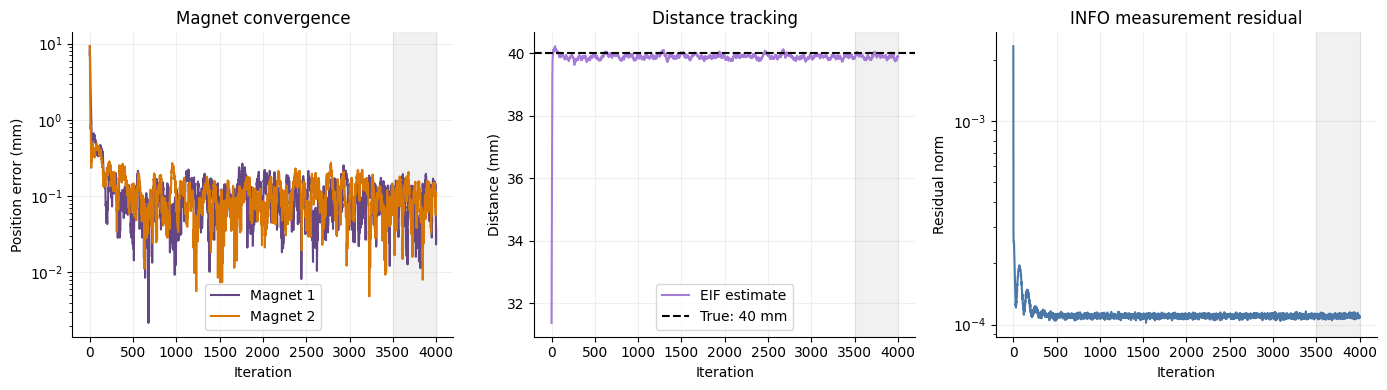

In [ ]:
iterations = np.arange(len(eif_states))
analysis_start = len(eif_states) - ANALYSIS_WINDOW
colors = ("#664785", "#D97706")

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for magnet_index, color in enumerate(colors):
    axes[0].plot(
        iterations, np.maximum(position_errors[:, magnet_index], 1e-8),
        color=color, label=f"Magnet {magnet_index + 1}",
    )
axes[0].axvspan(analysis_start, ITERS_TO_RUN, color="#D9D9D9", alpha=0.35)
axes[0].set_yscale("log")
axes[0].set_xlabel("Iteration")
axes[0].set_ylabel("Position error (mm)")
axes[0].set_title("Magnet convergence")
axes[0].legend()

axes[1].plot(iterations, estimated_distance, color="#A77CD9", label="INFO estimate")
axes[1].axhline(distance, color="black", linestyle="--", label="True: 40 mm")
axes[1].axvspan(analysis_start, ITERS_TO_RUN, color="#D9D9D9", alpha=0.35)
axes[1].set_xlabel("Iteration")
axes[1].set_ylabel("Distance (mm)")
axes[1].set_title("Distance tracking")
axes[1].legend()

filter_iterations = np.arange(1, len(residual_norms) + 1)
axes[2].plot(filter_iterations, np.maximum(residual_norms, 1e-12), color="#4C78A8")
axes[2].axvspan(analysis_start, ITERS_TO_RUN, color="#D9D9D9", alpha=0.35)
axes[2].set_yscale("log")
axes[2].set_xlabel("Iteration")
axes[2].set_ylabel("Residual norm")
axes[2].set_title("INFO measurement residual")

for ax in axes:
    ax.grid(alpha=0.2)
    ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()